# Dense MNIST with PyTorch

This complete workflow implements the dense MNIST experiment from the
[Neural Networks](../index.md) chapter in **PyTorch**.

The official 60,000-example training collection is divided with a seeded,
stratified split into 50,000 training and 10,000 validation samples. The
official 10,000-example test set remains untouched until final evaluation.

The example uses five epochs. To run it more quickly, set `EPOCHS` to 1 or 2
in the data-loading cell.

The notebook is self-contained in Google Colab. Select **Runtime → Run all**;
the runtime will use its installed PyTorch stack. The Keras alternative uses
that same runtime through the Keras 3 high-level API.

## Runtime dependency check

In [1]:
import importlib.util

required = {'torch': 'torch', 'torchvision': 'torchvision'}
missing = [
    package for module, package in required.items()
    if importlib.util.find_spec(module) is None
]
if missing:
    raise RuntimeError(
        "Missing notebook dependencies: "
        + ", ".join(missing)
        + ". Locally run `uv sync --group notebooks`; Colab normally "
        "provides these frameworks, so restart the runtime and try again."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports and reproducibility

In [3]:
import hashlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

print(f"PyTorch {torch.__version__}")

PyTorch 2.13.0


## Load data and create the shared split

In [4]:
SEED = 42
EPOCHS = 5  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 128  # Number of images used for each parameter update.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)  # Prefer repeatable operations when available.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

data_root = Path(
    os.getenv(
        "HELIO_DATA_DIR",
        Path.home() / ".cache" / "helio-data-methods",
    )
)
development_dataset = datasets.MNIST(data_root, train=True, download=True)
test_dataset = datasets.MNIST(data_root, train=False, download=True)
x_development = development_dataset.data.numpy()
y_development = development_dataset.targets.numpy()
x_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=10_000,
    random_state=SEED,
    stratify=y_development,
)

split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices]
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices]
x_test = x_test.astype("float32") / 255.0

assert set(train_indices).isdisjoint(validation_indices)
print(f"device: {DEVICE}")
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

device: mps
split signature: 829d1431018b38bc
train=50,000, validation=10,000, test=10,000, epochs=5


## Inspect class coverage

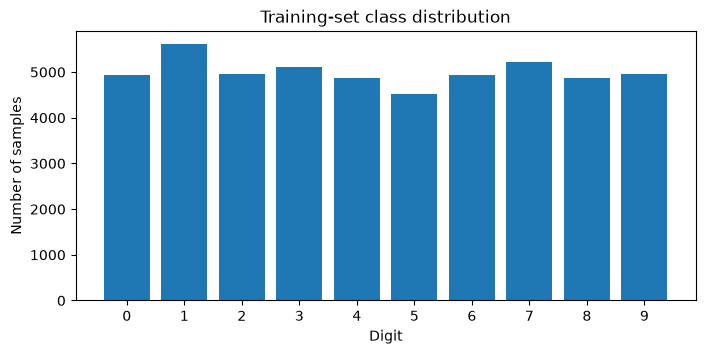

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Digit",
    ylabel="Number of samples",
    xticks=np.arange(10),
)
plt.show()

## Model configuration

This complete workflow preserves the source architecture and dropout rate.

In [6]:
DROPOUT_RATE = 0.5
print(f"dropout rate: {DROPOUT_RATE}")

dropout rate: 0.5


## Create data loaders

In [7]:
def tensor_dataset(images, labels):
    return TensorDataset(
        torch.from_numpy(images),
        torch.from_numpy(labels).long(),
    )


loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    tensor_dataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
)
validation_loader = DataLoader(
    tensor_dataset(x_validation, y_validation),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    tensor_dataset(x_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

## Build the dense classifier

In [8]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 200),
    nn.ReLU(),
    nn.Linear(200, 150),
    nn.ReLU(),
    nn.Dropout(DROPOUT_RATE),
    nn.Linear(150, 10),
).to(DEVICE)
loss_function = nn.CrossEntropyLoss()  # Classification error for the ten digits.
optimizer = torch.optim.Adam(model.parameters())  # Adam updates the model weights.
print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=200, bias=True)
  (2): ReLU()
  (3): Linear(in_features=200, out_features=150, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=150, out_features=10, bias=True)
)


## Train with validation evidence

In [9]:
def run_epoch(data_loader, training):
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in data_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        if training:
            optimizer.zero_grad()
        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = loss_function(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * len(labels)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += len(labels)

    return total_loss / total_examples, total_correct / total_examples


history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
for epoch in range(EPOCHS):
    train_loss, train_accuracy = run_epoch(train_loader, training=True)
    validation_loss, validation_accuracy = run_epoch(
        validation_loader, training=False
    )
    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(validation_loss)
    history["val_accuracy"].append(validation_accuracy)
    print(
        f"epoch {epoch + 1}/{EPOCHS} - "
        f"loss={train_loss:.4f} - accuracy={train_accuracy:.4f} - "
        f"val_loss={validation_loss:.4f} - "
        f"val_accuracy={validation_accuracy:.4f}"
    )

epoch 1/5 - loss=0.4755 - accuracy=0.8608 - val_loss=0.2084 - val_accuracy=0.9394


epoch 2/5 - loss=0.1893 - accuracy=0.9450 - val_loss=0.1384 - val_accuracy=0.9576


epoch 3/5 - loss=0.1313 - accuracy=0.9611 - val_loss=0.1108 - val_accuracy=0.9669


epoch 4/5 - loss=0.0986 - accuracy=0.9714 - val_loss=0.0991 - val_accuracy=0.9695


epoch 5/5 - loss=0.0788 - accuracy=0.9769 - val_loss=0.0863 - val_accuracy=0.9742


## Inspect learning curves

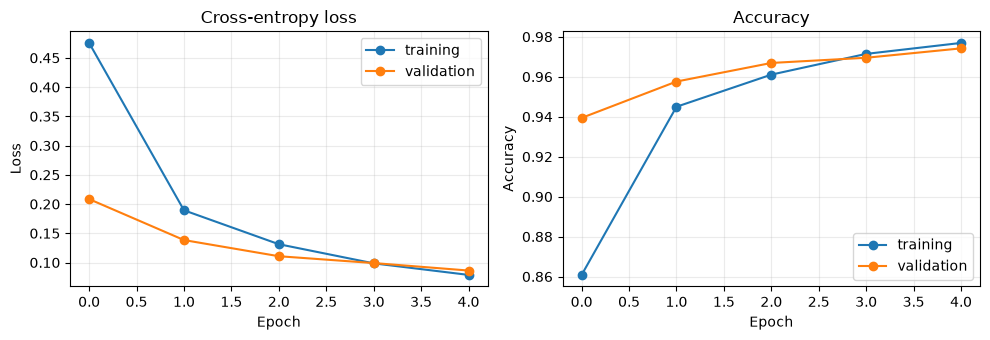

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history["loss"], marker="o", label="training")
axes[0].plot(history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch", ylabel="Loss")
axes[1].plot(history["accuracy"], marker="o", label="training")
axes[1].plot(history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Evaluate once on the held-out test set

In [11]:
model.eval()
all_logits = []
all_labels = []
test_loss_total = 0.0
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(DEVICE))
        test_loss_total += loss_function(logits, labels.to(DEVICE)).item() * len(labels)
        all_logits.append(logits.cpu())
        all_labels.append(labels)

test_logits = torch.cat(all_logits).numpy()
test_targets = torch.cat(all_labels).numpy()
test_predictions = test_logits.argmax(axis=1)
test_loss = test_loss_total / len(test_targets)
test_accuracy = accuracy_score(test_targets, test_predictions)
cm = confusion_matrix(test_targets, test_predictions, labels=np.arange(10))

print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        test_targets,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
assert cm.shape == (10, 10)

test loss: 0.0777
test accuracy: 0.9750
              precision    recall  f1-score   support

           0      0.975     0.986     0.980       980
           1      0.988     0.991     0.989      1135
           2      0.973     0.980     0.976      1032
           3      0.969     0.976     0.972      1010
           4      0.970     0.986     0.978       982
           5      0.982     0.966     0.974       892
           6      0.973     0.980     0.977       958
           7      0.970     0.968     0.969      1028
           8      0.982     0.952     0.967       974
           9      0.969     0.962     0.966      1009

    accuracy                          0.975     10000
   macro avg      0.975     0.975     0.975     10000
weighted avg      0.975     0.975     0.975     10000



## Inspect class-level errors

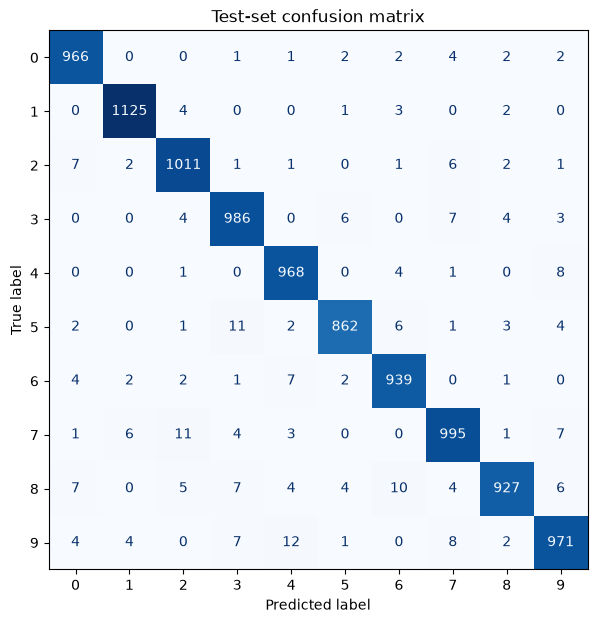

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Test-set confusion matrix")
plt.show()

## Inspect representative mistakes

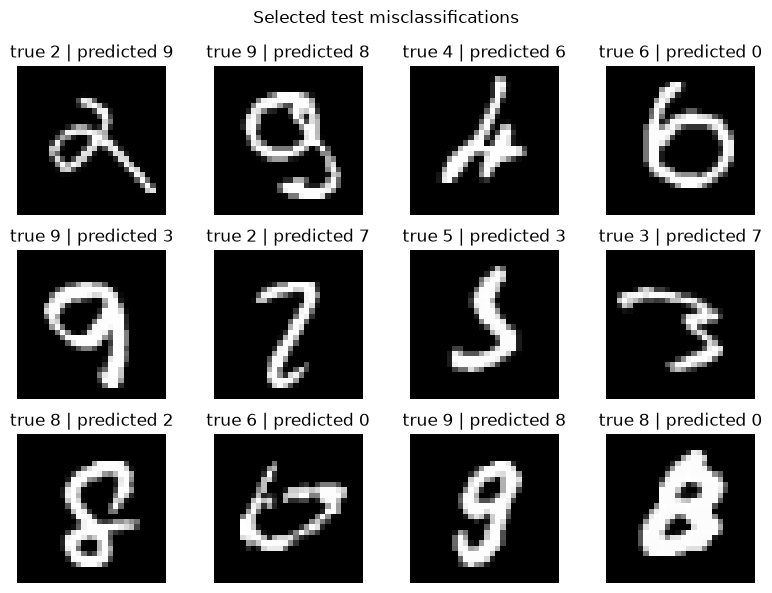

In [13]:
wrong = np.flatnonzero(test_predictions != test_targets)
chosen = wrong[:12]
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for axis, sample_index in zip(axes.flat, chosen):
    axis.imshow(x_test[sample_index], cmap="gray")
    axis.set_title(
        f"true {test_targets[sample_index]} | "
        f"predicted {test_predictions[sample_index]}"
    )
    axis.axis("off")
for axis in axes.flat[len(chosen):]:
    axis.axis("off")
fig.suptitle("Selected test misclassifications")
plt.tight_layout()
plt.show()

## Try it yourself

Change one choice at a time and keep the data split and evaluation unchanged:

- change dropout from `0.5` to `0.25` and compare the validation curves.
- change one dense-layer width and inspect the parameter count.
- try a smaller Adam learning rate while keeping the split fixed.